   Feature1  Feature2
0  0.682988 -0.345203
1  2.040990 -0.131615
2 -0.139752  0.454391
3  0.885748  0.286342
4  1.182459 -0.497711
5  1.019208 -0.425466
6  0.389362 -0.247117
7 -0.560385  0.712681
8  0.901844  0.053931
9  0.206748  0.006208
Shape: (300, 2)


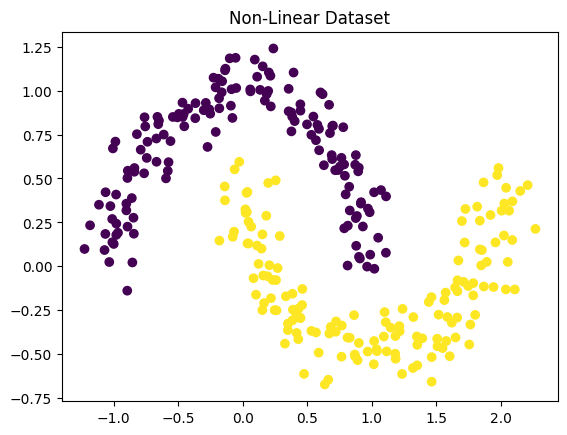

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Create Dataset
X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

# DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

# First 10 rows
print(df.head(10))

# Shape
print("Shape:", df.shape)

# Plot
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis")
plt.title("Non-Linear Dataset")
plt.show()

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Data (First 5 Rows):")
print(X_scaled[:5])

Scaled Data (First 5 Rows):
[[ 0.20818063 -1.19715111]
 [ 1.76014199 -0.77211765]
 [-0.73206846  0.39401072]
 [ 0.43989977  0.05960015]
 [ 0.77898869 -1.50063466]]


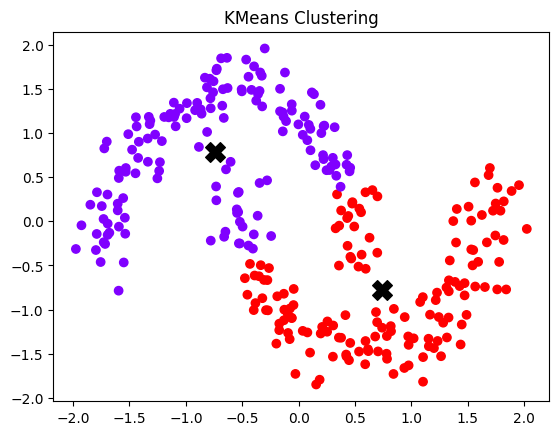

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap="rainbow")
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            color="black", marker="X", s=200)
plt.title("KMeans Clustering")
plt.show()

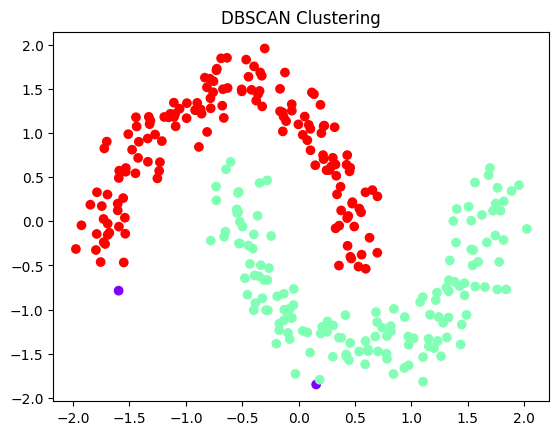

Cluster Labels:
[ 0  0  0  1  0  0  0  1  1  0  0  1  0  1  0  0  0  0  1  0  1  1  0  0
  1  1  0  0  0  0  1  0  1  1  0  1  1  1  1  1  1  1  0  1  1  1  0  0
  1  0  0  1  0  1  0  0  1  1  0  1  0  1  1  0  0  1  1  0  1  0  1  1
  0  0  1  0  1  1  1  0  0  0  1  1  1  1  1  1  1  1  0  1  1  0  1  1
  0 -1  0  1  0  1  1  0  0  0  1  1  0  1  1  0  1  0  0  1  1  0  0  0
  1  0  0  0  1  0  1  1  0  0  1  1  0  1  0  0  0  0  0  1  1  1  0  1
 -1  0  1  1  1  1  0  1  0  0  0  0  0  1  0  1  0  0  1  1  1  1  0  0
  0  1  1  0  0  1  1  0  1  1  0  1  0  1  0  0  1  0  0  0  1  1  1  0
  0  0  0  1  0  0  1  0  1  1  1  0  0  0  0  1  1  1  1  0  1  1  0  1
  1  0  0  1  1  0  0  0  1  0  1  1  0  0  1  0  0  0  0  1  1  1  0  0
  0  0  0  1  0  1  0  0  0  1  1  1  1  1  1  1  1  1  0  1  1  1  0  1
  1  0  0  1  0  0  1  1  0  0  0  0  0  1  1  0  0  1  0  0  0  0  1  1
  0  1  1  0  1  0  1  0  1  1  0  1]


In [4]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.3, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=db_labels, cmap="rainbow")
plt.title("DBSCAN Clustering")
plt.show()

print("Cluster Labels:")
print(db_labels)

In [5]:
import numpy as np

print("Unique Clusters:", np.unique(db_labels))
print("Number of Clusters:",
      len(set(db_labels)) - (1 if -1 in db_labels else 0))
print("Noise Points:",
      list(db_labels).count(-1))

Unique Clusters: [-1  0  1]
Number of Clusters: 2
Noise Points: 2


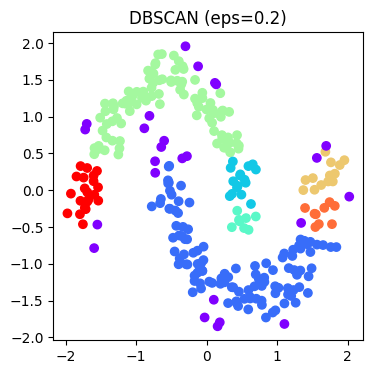

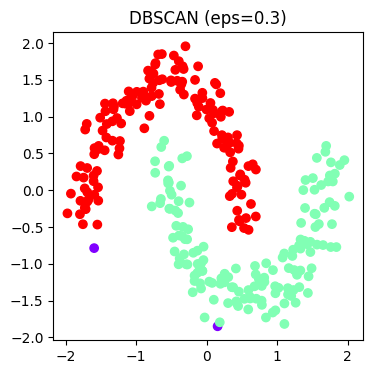

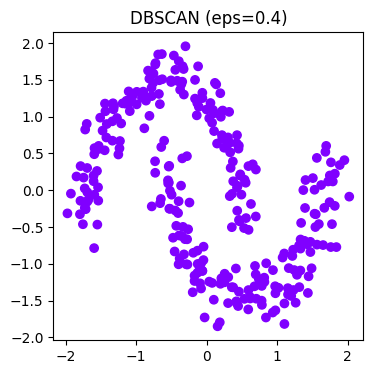

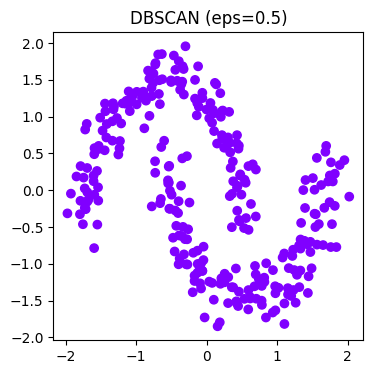

In [6]:
eps_values = [0.2, 0.3, 0.4, 0.5]

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)

    plt.figure(figsize=(4,4))
    plt.scatter(X_scaled[:,0], X_scaled[:,1],
                c=labels, cmap="rainbow")
    plt.title(f"DBSCAN (eps={eps})")
    plt.show()

In [7]:
from sklearn.datasets import make_classification

# Create High-Dimensional Dataset
X_hd, y_hd = make_classification(
    n_samples=300,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    random_state=42
)

print("Dataset Shape:", X_hd.shape)

Dataset Shape: (300, 10)


In [8]:
from sklearn.decomposition import PCA

# Reduce 10 features to 2 features
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_hd)

print("PCA Shape:", X_pca.shape)
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

PCA Shape: (300, 2)
Explained Variance Ratio:
[0.43733998 0.17407099]


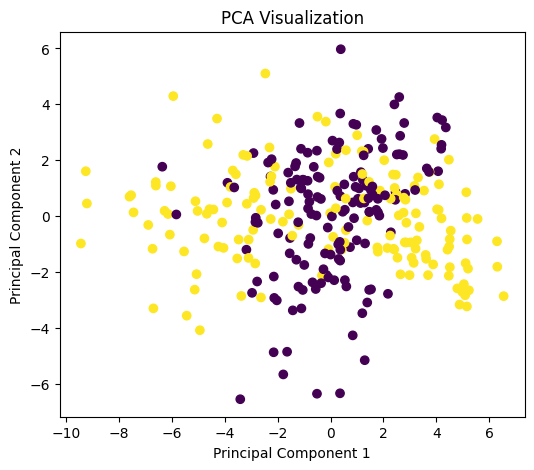

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=y_hd, cmap="viridis")
plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

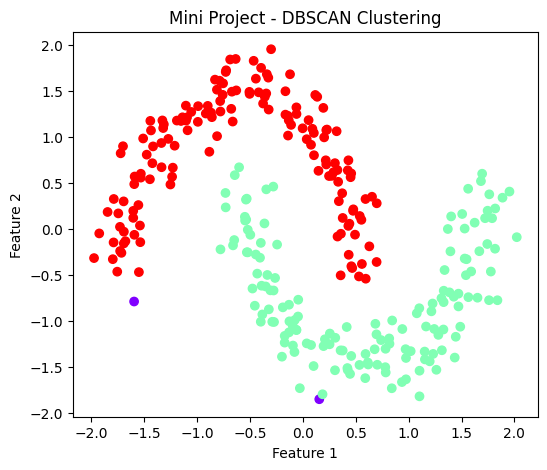

Unique Clusters: {np.int64(0), np.int64(1), np.int64(-1)}


In [10]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Dataset
X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Plot
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=labels, cmap="rainbow")
plt.title("Mini Project - DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("Unique Clusters:", set(labels))